In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table

# --- 설정값 ---
chip_size = 13.65 * u.arcmin
chip_gap = 12.83 * u.arcmin
# tile_size = chip_size + chip_gap

tile_size = (5*chip_size + 3*chip_gap)/2

# tile_fov_deg = tile_size.to(u.deg).value # calculated value
tile_fov_deg = 0.75 # official webpage value

overlap_frac = 0.10  # 오버랩 비율
effective_step = tile_fov_deg * (1 - overlap_frac)

# --- Grid 계산 ---
dec_range = np.arange(-30, 90 + effective_step, effective_step)
skygrid_data = []

for dec in dec_range:
    dec_rad = np.deg2rad(dec)
    if np.abs(dec) >= 89.0:
        continue  # 극 영역은 생략하거나 HEALPix 사용 권장
    ra_step = effective_step / np.cos(dec_rad)  # 위도 보정
    ra_range = np.arange(0, 360, ra_step)
    for ra in ra_range:
        center = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
        skygrid_data.append((center.ra.deg, center.dec.deg))

print("skygrid_data.shape: ", len(skygrid_data))

skygrid_data.shape:  68223


In [2]:
import os

obs = 'UKIRT'
path_save = f'../data/skygrid/{obs}'
os.makedirs(path_save, exist_ok=True)

In [3]:
(tile_size*tile_size).to(u.deg**2)

<Quantity 0.79121025 deg2>

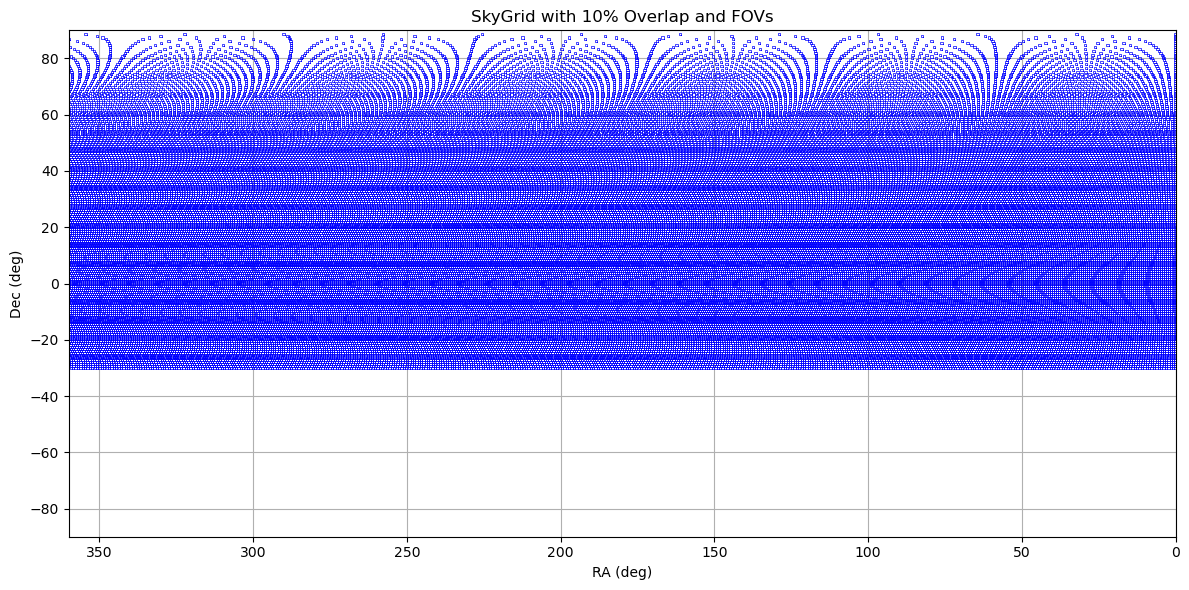

In [4]:

# --- 사각형 꼭짓점 계산 함수 ---
def compute_tile_polygon(center_ra, center_dec, size_deg):
    half = size_deg / 2
    return [
        (center_ra - half, center_dec - half),
        (center_ra - half, center_dec + half),
        (center_ra + half, center_dec + half),
        (center_ra + half, center_dec - half),
        (center_ra - half, center_dec - half),  # close polygon
    ]

# --- 시각화 ---
fig, ax = plt.subplots(figsize=(12, 6))
for ra, dec in skygrid_data:
    corners = compute_tile_polygon(ra, dec, tile_fov_deg)
    x, y = zip(*corners)
    ax.plot(x, y, color='blue', linewidth=0.5)  # 타일 경계선
    # ax.plot(ra, dec, 'ro', markersize=1.5)      # 중심점

ax.set_xlim(360, 0)
ax.set_ylim(-90, 90)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"SkyGrid with {int(overlap_frac * 100)}% Overlap and FOVs")
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
# --- 사각형 타일 꼭짓점 계산 ---
def compute_tile_corners(ra_deg, dec_deg, fov_deg):
    half = fov_deg / 2
    return [
        (ra_deg - half, dec_deg - half),
        (ra_deg - half, dec_deg + half),
        (ra_deg + half, dec_deg + half),
        (ra_deg + half, dec_deg - half),
        (ra_deg - half, dec_deg - half),
    ]

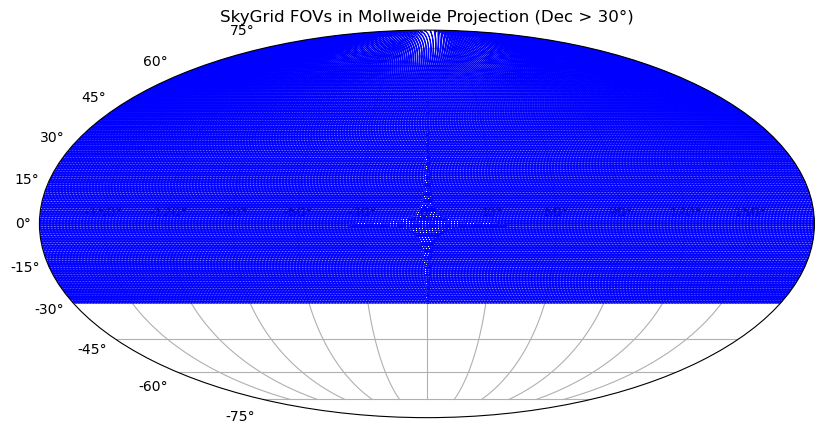

In [6]:
# --- Mollweide 시각화 ---
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="mollweide")

for ra_deg, dec_deg in skygrid_data:
    # if dec_deg < 30:
        # continue
    corners = compute_tile_corners(ra_deg, dec_deg, tile_fov_deg)
    ra_vals = [np.deg2rad(180 - ra) for ra, dec in corners]  # RA 중심 좌우 반전
    dec_vals = [np.deg2rad(dec) for ra, dec in corners]
    ax.plot(ra_vals, dec_vals, color="blue", linewidth=0.5)

ax.set_title("SkyGrid FOVs in Mollweide Projection (Dec > 30°)")
ax.grid(True)
plt.show()

In [7]:
skygrid_data[:3]

[(0.0, -30.0), (0.7794228634059948, -30.0), (1.5588457268119895, -30.0)]

In [8]:
corners

[(354.168555203066, 88.42500000000013),
 (354.168555203066, 89.17500000000013),
 (354.918555203066, 89.17500000000013),
 (354.918555203066, 88.42500000000013),
 (354.168555203066, 88.42500000000013)]

In [9]:
center_table = Table()
center_table['#id'] = np.arange(len(skygrid_data))
center_table['ra'] = [skygrid_data[ii][0] for ii in range(len(skygrid_data))]
center_table['dec'] = [skygrid_data[ii][1] for ii in range(len(skygrid_data))]

polygon_table = Table()
polygon_table['ra1'] = np.zeros(len(skygrid_data))
polygon_table['dec1'] = np.zeros(len(skygrid_data))
polygon_table['ra2'] = np.zeros(len(skygrid_data))
polygon_table['dec2'] = np.zeros(len(skygrid_data))
polygon_table['ra3'] = np.zeros(len(skygrid_data))
polygon_table['dec3'] = np.zeros(len(skygrid_data))
polygon_table['ra4'] = np.zeros(len(skygrid_data))
polygon_table['dec4'] = np.zeros(len(skygrid_data))

for ii, (ra_deg, dec_deg) in enumerate(skygrid_data):
    corners = compute_tile_corners(ra_deg, dec_deg, tile_fov_deg)
    polygon_table['ra1'][ii] = corners[0][0]
    polygon_table['dec1'][ii] = corners[0][1]
    polygon_table['ra2'][ii] = corners[1][0]
    polygon_table['dec2'][ii] = corners[1][1]
    polygon_table['ra3'][ii] = corners[2][0]
    polygon_table['dec3'][ii] = corners[2][1]
    polygon_table['ra4'][ii] = corners[3][0]
    polygon_table['dec4'][ii] = corners[3][1]
    

In [10]:
path_center_table = f"{path_save}/displaycenter.txt"
path_polygon_table = f"{path_save}/displayfootprint.txt"

center_table.write(path_center_table, format='csv')
polygon_table.write(path_polygon_table, format='csv')


OSError: File ../data/skygrid/UKIRT/displaycenter.txt already exists. If you mean to replace it then use the argument "overwrite=True".